
# Task 2 — Mantis Foundation Model + Trainable MLP Head (Fast Aligned Protocol)

This version avoids the extremely slow `MantisTrainer.fit()` loop (the previous run was still at epoch 172/500).
Instead:

1. the pretrained **Mantis-8M** encoder is used once as a frozen feature extractor;
2. its embeddings are cached;
3. a small stochastic **MLP classification head** is trained with the same neural-model protocol used in Task 2.

This is a valid **foundation-model representation + supervised classifier** experiment and is much more practical for the 5,265-sample Task 2 benchmark.

## Protocol kept aligned with the six existing models

- same canonical dataset
- same 7-hour window (`t-3 ... t+3`)
- same 2 input channels
- same 3 classes
- same grouped-random and spatial-holdout manifests
- seeds: 42, 52, 62
- Macro-F1 primary metric
- class-weighted cross entropy
- AdamW
- max 35 epochs
- batch size 64
- early stopping patience 6 based on validation Macro-F1
- test set used only after validation selection
- final mean ± SD across three seeds

Only the model-specific representation differs: Mantis produces pretrained embeddings before the supervised MLP head.


In [1]:

# Run once if needed.
%pip install -q mantis-tsfm scikit-learn pandas numpy matplotlib torch huggingface_hub


Note: you may need to restart the kernel to use updated packages.


In [10]:

from pathlib import Path
import copy
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

SEEDS = [42, 52, 62]
CLASS_ORDER = ["NORMAL", "ACCIDENT", "OTHER_DISRUPTION"]
CLASS_TO_ID = {"NORMAL": 0, "ACCIDENT": 1, "OTHER_DISRUPTION": 2}

# ===== EDIT ONLY IF YOUR PATHS DIFFER =====
DATA_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/canonical_dataset_revised.csv")
GROUPED_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/grouped_random_split_manifest_revised.csv")
SPATIAL_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/spatial_split_manifest_revised.csv")


MANTIS_CHECKPOINT = "paris-noah/Mantis-8M"
MANTIS_LENGTH = 512

MAX_EPOCHS = 35
BATCH_SIZE = 64
PATIENCE = 6
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0

# Small validation grid for the downstream head.
HEAD_CONFIGS = [
    {"hidden": 64,  "dropout": 0.20, "lr": 1e-3},
    {"hidden": 128, "dropout": 0.30, "lr": 5e-4},
]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cpu


## 1. Helpers

In [11]:

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def first_existing(columns, candidates):
    lower_map = {str(c).lower(): c for c in columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None


## 2. Load canonical data and frozen split manifests

In [12]:

df = pd.read_csv(DATA_PATH)
grouped_manifest = pd.read_csv(GROUPED_MANIFEST_PATH)
spatial_manifest = pd.read_csv(SPATIAL_MANIFEST_PATH)

print("Canonical:", df.shape)
print("Grouped manifest:", grouped_manifest.shape)
print("Spatial manifest:", spatial_manifest.shape)
display(df.head())


Canonical: (5265, 16)
Grouped manifest: (5265, 5)
Spatial manifest: (5265, 5)


,event_sample_id,station_id,anchor_time,window_start,window_end,target_class,split_group_id,sample_type,flow_t_minus_3,flow_t_minus_2,flow_t_minus_1,flow_t0,flow_t_plus_1,flow_t_plus_2,flow_t_plus_3,all_zero_flow_window
0,INCIDENT__219427-webtirf__7120,7120,2025-01-01 04:00:00,2025-01-01 01:00:00,2025-01-01 07:00:00,OTHER_DISRUPTION,GROUP__7120__0001,INCIDENT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
1,INCIDENT__219427-webtirf__7121,7121,2025-01-01 04:00:00,2025-01-01 01:00:00,2025-01-01 07:00:00,OTHER_DISRUPTION,GROUP__7121__0001,INCIDENT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
2,INCIDENT__219440.0-webtirf__7168,7168,2025-01-01 11:00:00,2025-01-01 08:00:00,2025-01-01 14:00:00,OTHER_DISRUPTION,GROUP__7168__0001,INCIDENT,13.0,4.0,13.0,10.0,16.0,12.0,7.0,False
3,INCIDENT__219468-webtirf__F3FWY003,F3FWY003,2025-01-02 01:00:00,2025-01-01 22:00:00,2025-01-02 04:00:00,ACCIDENT,GROUP__F3FWY003__0001,INCIDENT,0.0,0.0,31.0,19.0,30.0,27.0,0.0,False
4,INCIDENT__219481-webtirf__7179,7179,2025-01-02 03:00:00,2025-01-02 00:00:00,2025-01-02 06:00:00,OTHER_DISRUPTION,GROUP__7179__0001,INCIDENT,21.0,30.0,33.0,34.0,73.0,105.0,160.0,False


## 3. Build the aligned 7 × 2 sequence

In [13]:

LABEL_COL = first_existing(
    df.columns,
    ["target_class", "label", "class", "target", "incident_class", "task2_class", "condition"]
)

FLOW_COLUMNS = [
    "flow_t_minus_3",
    "flow_t_minus_2",
    "flow_t_minus_1",
    "flow_t0",
    "flow_t_plus_1",
    "flow_t_plus_2",
    "flow_t_plus_3",
]

if LABEL_COL is None:
    raise ValueError(f"Target column not found. Available columns: {list(df.columns)}")

missing = [c for c in FLOW_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Missing flow columns: {missing}")

print("Target:", LABEL_COL)
print(df[LABEL_COL].value_counts())


Target: target_class
target_class
NORMAL              3581
OTHER_DISRUPTION    1179
ACCIDENT             505
Name: count, dtype: int64


In [14]:

def build_two_channel_input(frame, flow_columns):
    flow = frame[flow_columns].astype(float).to_numpy()

    if np.any(~np.isfinite(flow)):
        raise ValueError("Non-finite flow values found.")

    # Channel 1: log1p(flow)
    ch1 = np.log1p(np.clip(flow, 0, None))

    # Channel 2: pre-event-normalized relative change
    baseline = np.median(flow[:, :3], axis=1, keepdims=True)
    ch2 = np.clip((flow - baseline) / (baseline + 1.0), -5.0, 5.0)

    return np.stack([ch1, ch2], axis=1).astype(np.float32)  # [N, C, L]


X7 = build_two_channel_input(df, FLOW_COLUMNS)

labels = df[LABEL_COL].astype(str).str.upper().str.strip()
unknown = sorted(set(labels) - set(CLASS_ORDER))
if unknown:
    raise ValueError(f"Unexpected labels: {unknown}")

y = labels.map(CLASS_TO_ID).to_numpy(dtype=np.int64)

print("X7 shape:", X7.shape)
print("y shape:", y.shape)
print("Class mapping:", CLASS_TO_ID)


X7 shape: (5265, 2, 7)
y shape: (5265,)
Class mapping: {'NORMAL': 0, 'ACCIDENT': 1, 'OTHER_DISRUPTION': 2}


## 4. Adapt 7 steps to the pretrained Mantis input length

In [15]:

def resize_for_mantis(X, target_length=MANTIS_LENGTH):
    xt = torch.as_tensor(X, dtype=torch.float32)
    xt = F.interpolate(xt, size=target_length, mode="linear", align_corners=False)
    return xt.numpy().astype(np.float32)

X_mantis = resize_for_mantis(X7)
print("Mantis-ready input:", X_mantis.shape)


Mantis-ready input: (5265, 2, 512)


## 5. Resolve train / validation / test indices

In [16]:

def normalize_split_name(x):
    x = str(x).strip().lower()
    return {
        "train": "train", "training": "train",
        "val": "val", "valid": "val", "validation": "val",
        "test": "test", "testing": "test",
    }.get(x, x)


def resolve_manifest_indices(dataframe, manifest):
    split_col = first_existing(manifest.columns, ["split", "partition", "set", "subset"])
    if split_col is None:
        raise ValueError(f"Split column not found: {list(manifest.columns)}")

    data_id_col = first_existing(
        dataframe.columns,
        ["event_sample_id", "sample_id", "id", "window_id", "record_id"]
    )
    manifest_id_col = first_existing(
        manifest.columns,
        ["event_sample_id", "sample_id", "id", "window_id", "record_id"]
    )

    m = manifest.copy()
    m["_split"] = m[split_col].map(normalize_split_name)

    if data_id_col and manifest_id_col:
        if dataframe[data_id_col].astype(str).duplicated().any():
            raise ValueError(f"{data_id_col} must be unique.")

        lookup = pd.Series(
            np.arange(len(dataframe)),
            index=dataframe[data_id_col].astype(str)
        )
        ids = m[manifest_id_col].astype(str)

        missing_ids = ids[~ids.isin(lookup.index)]
        if len(missing_ids):
            raise ValueError(f"{len(missing_ids)} manifest IDs not found in canonical data.")

        m["_idx"] = ids.map(lookup).astype(int)
    else:
        if len(m) != len(dataframe):
            raise ValueError("No shared ID and row counts differ.")
        m["_idx"] = np.arange(len(dataframe))

    out = {
        s: m.loc[m["_split"] == s, "_idx"].to_numpy(dtype=int)
        for s in ["train", "val", "test"]
    }

    if any(len(v) == 0 for v in out.values()):
        raise ValueError(f"Empty split: { {k: len(v) for k, v in out.items()} }")

    return out


grouped_idx = resolve_manifest_indices(df, grouped_manifest)
spatial_idx = resolve_manifest_indices(df, spatial_manifest)

print("Grouped:", {k: len(v) for k, v in grouped_idx.items()})
print("Spatial:", {k: len(v) for k, v in spatial_idx.items()})


Grouped: {'train': 3685, 'val': 784, 'test': 796}
Spatial: {'train': 3703, 'val': 806, 'test': 756}


## 6. Load pretrained Mantis-8M and extract embeddings once

In [17]:

from mantis.architecture import MantisV1
from mantis.trainer import MantisTrainer

set_seed(42)

network = MantisV1(device=DEVICE)
network = network.from_pretrained(MANTIS_CHECKPOINT)
mantis = MantisTrainer(device=DEVICE, network=network)

print("Loaded:", MANTIS_CHECKPOINT)


Loaded: paris-noah/Mantis-8M


In [18]:

# IMPORTANT:
# Do not call mantis.fit() here. That was the source of the 500-epoch slow run.
# transform() extracts the pretrained representations only once.

Z = mantis.transform(X_mantis)
Z = np.asarray(Z, dtype=np.float32)

if Z.ndim > 2:
    Z = Z.reshape(len(Z), -1)

print("Embedding shape:", Z.shape)
assert len(Z) == len(df)


Embedding shape: (5265, 512)



## 7. Standardize embeddings using TRAIN statistics only

For each evaluation scheme, mean and standard deviation are computed only from the
training partition. Validation and test embeddings are transformed with those same
training statistics, preventing leakage.


In [19]:

def standardize_by_train(Z, idx):
    mu = Z[idx["train"]].mean(axis=0, keepdims=True)
    sd = Z[idx["train"]].std(axis=0, keepdims=True)
    sd[sd < 1e-8] = 1.0

    Zs = (Z - mu) / sd
    return Zs.astype(np.float32)


## 8. MLP classification head

In [20]:

class MLPHead(torch.nn.Module):
    def __init__(self, input_dim, hidden, dropout, num_classes=3):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def class_weights_from_train(y_train):
    counts = np.bincount(y_train, minlength=len(CLASS_ORDER)).astype(np.float32)
    weights = len(y_train) / (len(CLASS_ORDER) * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def make_loader(Z_arr, y_arr, indices, shuffle):
    ds = TensorDataset(
        torch.tensor(Z_arr[indices], dtype=torch.float32),
        torch.tensor(y_arr[indices], dtype=torch.long),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)


## 9. Metrics

In [21]:

def compute_metrics(y_true, y_pred):
    p, r, f1c, _ = precision_recall_fscore_support(
        y_true, y_pred,
        labels=np.arange(len(CLASS_ORDER)),
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_per_class": p,
        "recall_per_class": r,
        "f1_per_class": f1c,
        "confusion_matrix": confusion_matrix(
            y_true, y_pred, labels=np.arange(len(CLASS_ORDER))
        ),
    }


## 10. Train one head configuration with early stopping

In [22]:

@torch.no_grad()
def predict_head(model, Z_arr, indices):
    model.eval()
    loader = make_loader(Z_arr, y, indices, shuffle=False)

    preds = []
    for xb, _ in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds.append(logits.argmax(dim=1).cpu().numpy())

    return np.concatenate(preds)


def train_one_head(Z_arr, y_arr, idx, seed, config):
    set_seed(seed)

    model = MLPHead(
        input_dim=Z_arr.shape[1],
        hidden=config["hidden"],
        dropout=config["dropout"],
        num_classes=len(CLASS_ORDER),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=WEIGHT_DECAY,
    )

    criterion = torch.nn.CrossEntropyLoss(
        weight=class_weights_from_train(y_arr[idx["train"]])
    )

    train_loader = make_loader(Z_arr, y_arr, idx["train"], shuffle=True)

    best_state = None
    best_val_f1 = -np.inf
    best_epoch = 0
    no_improve = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

        val_pred = predict_head(model, Z_arr, idx["val"])
        val_f1 = f1_score(
            y_arr[idx["val"]],
            val_pred,
            average="macro",
            zero_division=0,
        )

        if val_f1 > best_val_f1 + 1e-6:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= PATIENCE:
            break

    model.load_state_dict(best_state)

    return model, best_val_f1, best_epoch


## 11. Validation-based head selection and final test evaluation

In [23]:

def run_one_seed(Z_raw, y_arr, idx, seed):
    Zs = standardize_by_train(Z_raw, idx)

    candidates = []

    for config in HEAD_CONFIGS:
        model, val_f1, best_epoch = train_one_head(
            Zs, y_arr, idx, seed, config
        )

        candidates.append({
            "config": config,
            "model": model,
            "val_macro_f1": val_f1,
            "best_epoch": best_epoch,
        })

        print(
            f"seed={seed} | config={config} | "
            f"val Macro-F1={val_f1:.4f} | epoch={best_epoch}"
        )

    best = max(candidates, key=lambda z: z["val_macro_f1"])

    test_pred = predict_head(best["model"], Zs, idx["test"])
    metrics = compute_metrics(y_arr[idx["test"]], test_pred)

    return {
        "seed": seed,
        "best_config": best["config"],
        "best_epoch": best["best_epoch"],
        "val_macro_f1": best["val_macro_f1"],
        "y_true": y_arr[idx["test"]],
        "y_pred": test_pred,
        **metrics,
    }


## 12. Run grouped-random and spatial-holdout experiments

In [24]:

all_results = {"grouped": [], "spatial": []}

for split_name, idx in [
    ("grouped", grouped_idx),
    ("spatial", spatial_idx),
]:
    print(f"\n===== {split_name.upper()} =====")

    for seed in SEEDS:
        result = run_one_seed(Z, y, idx, seed)
        all_results[split_name].append(result)

        print(
            f"FINAL seed={seed} | "
            f"val Macro-F1={result['val_macro_f1']:.4f} | "
            f"test Macro-F1={result['macro_f1']:.4f}"
        )



===== GROUPED =====
seed=42 | config={'hidden': 64, 'dropout': 0.2, 'lr': 0.001} | val Macro-F1=0.3365 | epoch=11
seed=42 | config={'hidden': 128, 'dropout': 0.3, 'lr': 0.0005} | val Macro-F1=0.3412 | epoch=18
FINAL seed=42 | val Macro-F1=0.3412 | test Macro-F1=0.2990
seed=52 | config={'hidden': 64, 'dropout': 0.2, 'lr': 0.001} | val Macro-F1=0.3276 | epoch=10
seed=52 | config={'hidden': 128, 'dropout': 0.3, 'lr': 0.0005} | val Macro-F1=0.3609 | epoch=15
FINAL seed=52 | val Macro-F1=0.3609 | test Macro-F1=0.3102
seed=62 | config={'hidden': 64, 'dropout': 0.2, 'lr': 0.001} | val Macro-F1=0.3467 | epoch=2
seed=62 | config={'hidden': 128, 'dropout': 0.3, 'lr': 0.0005} | val Macro-F1=0.3517 | epoch=1
FINAL seed=62 | val Macro-F1=0.3517 | test Macro-F1=0.3441

===== SPATIAL =====
seed=42 | config={'hidden': 64, 'dropout': 0.2, 'lr': 0.001} | val Macro-F1=0.3290 | epoch=1
seed=42 | config={'hidden': 128, 'dropout': 0.3, 'lr': 0.0005} | val Macro-F1=0.3222 | epoch=6
FINAL seed=42 | val Macro

## 13. Mean ± SD overall results

In [25]:

rows = []

for split_name, results in all_results.items():
    for r in results:
        rows.append({
            "Split": split_name,
            "Seed": r["seed"],
            "Accuracy": r["accuracy"],
            "Balanced Accuracy": r["balanced_accuracy"],
            "Macro-F1": r["macro_f1"],
            "Validation Macro-F1": r["val_macro_f1"],
            "Best Epoch": r["best_epoch"],
            "Best Config": str(r["best_config"]),
        })

seed_results = pd.DataFrame(rows)
display(seed_results)

summary_rows = []

for split_name in ["grouped", "spatial"]:
    sdf = seed_results[seed_results["Split"] == split_name]

    summary_rows.append({
        "Model": "Mantis-8M + MLP head",
        "Split": split_name,
        "Accuracy": f"{sdf['Accuracy'].mean():.3f} ± {sdf['Accuracy'].std(ddof=1):.3f}",
        "Balanced Accuracy": f"{sdf['Balanced Accuracy'].mean():.3f} ± {sdf['Balanced Accuracy'].std(ddof=1):.3f}",
        "Macro-F1": f"{sdf['Macro-F1'].mean():.3f} ± {sdf['Macro-F1'].std(ddof=1):.3f}",
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,Split,Seed,Accuracy,Balanced Accuracy,Macro-F1,Validation Macro-F1,Best Epoch,Best Config
0,grouped,42,0.425879,0.306201,0.299006,0.341237,18,"{'hidden': 128, 'dropout': 0.3, 'lr': 0.0005}"
1,grouped,52,0.447236,0.313589,0.310173,0.360927,15,"{'hidden': 128, 'dropout': 0.3, 'lr': 0.0005}"
2,grouped,62,0.497487,0.367738,0.344146,0.351748,1,"{'hidden': 128, 'dropout': 0.3, 'lr': 0.0005}"
3,spatial,42,0.466931,0.323914,0.314148,0.328975,1,"{'hidden': 64, 'dropout': 0.2, 'lr': 0.001}"
4,spatial,52,0.458995,0.306517,0.305934,0.335721,3,"{'hidden': 64, 'dropout': 0.2, 'lr': 0.001}"
5,spatial,62,0.480159,0.301444,0.302991,0.335662,5,"{'hidden': 128, 'dropout': 0.3, 'lr': 0.0005}"


,Model,Split,Accuracy,Balanced Accuracy,Macro-F1
0,Mantis-8M + MLP head,grouped,0.457 ± 0.037,0.329 ± 0.034,0.318 ± 0.024
1,Mantis-8M + MLP head,spatial,0.469 ± 0.011,0.311 ± 0.012,0.308 ± 0.006


## 14. Per-class results

In [26]:

def per_class_summary(results, split_name):
    rows = []

    for i, class_name in enumerate(CLASS_ORDER):
        p = np.array([r["precision_per_class"][i] for r in results])
        rec = np.array([r["recall_per_class"][i] for r in results])
        f1c = np.array([r["f1_per_class"][i] for r in results])

        rows.append({
            "Split": split_name,
            "Class": class_name,
            "Precision": f"{p.mean():.6f} ± {p.std(ddof=1):.6f}",
            "Recall": f"{rec.mean():.6f} ± {rec.std(ddof=1):.6f}",
            "F1": f"{f1c.mean():.6f} ± {f1c.std(ddof=1):.6f}",
        })

    return pd.DataFrame(rows)


per_class_df = pd.concat([
    per_class_summary(all_results["grouped"], "grouped"),
    per_class_summary(all_results["spatial"], "spatial"),
], ignore_index=True)

display(per_class_df)


,Split,Class,Precision,Recall,F1
0,grouped,NORMAL,0.664928 ± 0.019017,0.577942 ± 0.053135,0.617988 ± 0.038369
1,grouped,ACCIDENT,0.095938 ± 0.027018,0.216216 ± 0.084392,0.132424 ± 0.041627
2,grouped,OTHER_DISRUPTION,0.220525 ± 0.025550,0.193370 ± 0.038674,0.202913 ± 0.014250
3,spatial,NORMAL,0.669007 ± 0.006944,0.607120 ± 0.019450,0.636483 ± 0.012708
4,spatial,ACCIDENT,0.082017 ± 0.026926,0.135135 ± 0.075240,0.101126 ± 0.041820
5,spatial,OTHER_DISRUPTION,0.182692 ± 0.010484,0.189621 ± 0.034572,0.185464 ± 0.022047


## 15. Aggregate confusion matrices

Grouped:


,NORMAL,ACCIDENT,OTHER_DISRUPTION
NORMAL,938,342,343
ACCIDENT,136,48,38
OTHER_DISRUPTION,335,103,105


Spatial:


,NORMAL,ACCIDENT,OTHER_DISRUPTION
NORMAL,938,237,370
ACCIDENT,139,30,53
OTHER_DISRUPTION,325,81,95


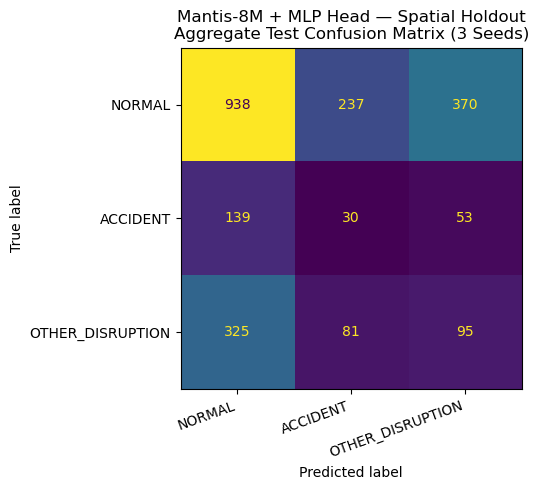

In [27]:

def aggregate_confusion(results):
    return np.sum([r["confusion_matrix"] for r in results], axis=0)

cm_grouped = aggregate_confusion(all_results["grouped"])
cm_spatial = aggregate_confusion(all_results["spatial"])

print("Grouped:")
display(pd.DataFrame(cm_grouped, index=CLASS_ORDER, columns=CLASS_ORDER))

print("Spatial:")
display(pd.DataFrame(cm_spatial, index=CLASS_ORDER, columns=CLASS_ORDER))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_spatial,
    display_labels=CLASS_ORDER,
)
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title("Mantis-8M + MLP Head — Spatial Holdout\nAggregate Test Confusion Matrix (3 Seeds)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(
    "mantis_mlp_spatial_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 16. Export results

In [28]:

seed_results.to_csv("mantis_mlp_seed_results.csv", index=False)
summary_df.to_csv("mantis_mlp_overall_summary.csv", index=False)
per_class_df.to_csv("mantis_mlp_per_class_summary.csv", index=False)

print("Saved:")
print("- mantis_mlp_seed_results.csv")
print("- mantis_mlp_overall_summary.csv")
print("- mantis_mlp_per_class_summary.csv")
print("- mantis_mlp_spatial_confusion_matrix.png")


Saved:
- mantis_mlp_seed_results.csv
- mantis_mlp_overall_summary.csv
- mantis_mlp_per_class_summary.csv
- mantis_mlp_spatial_confusion_matrix.png



## Recommended paper label

**Mantis-8M (pretrained frozen encoder + supervised MLP head)**

This should be described as a **time-series foundation-model baseline**, not as full end-to-end fine-tuning.

The 7-to-512 interpolation is a model-specific input adaptation and does not introduce additional temporal information.
